In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import gsw
plt.rcParams.update({'font.size': 20})

/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jupyter-vincent2/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
df_ker = pd.read_csv("/home/jupyter-vincent2/vincent/process_profiles/data/KERFIX/kerfix.csv",sep=";")
df_ker["TIME"] = pd.to_datetime(df_ker["profileID"].astype(str).str[:2].apply(lambda x: "19" + x if int(x) > 50 else "20" + x) + df_ker["profileID"].astype(str).str[2:], format="%Y%m")
df_ker["DEPTH"] = - gsw.conversions.z_from_p(df_ker["PRES"], lat = -50.6667, geo_strf_dyn_height=0, sea_surface_geopotential=0)
df_ker["SA"] = gsw.SA_from_SP(df_ker["PSAL"], df_ker["PRES"], lon = 68.4167, lat = -50.6667)
df_ker["CT"] = gsw.CT_from_t(df_ker["SA"], df_ker["TEMP"], df_ker["PRES"])
df_ker["sigma0"] = gsw.density.sigma0(df_ker["SA"], df_ker["CT"])
ds_ker = df_ker.reset_index(drop=True).set_index(["TIME","DEPTH"]).to_xarray()

In [3]:
def mld_calculation(ds):
    # MLD calculation

    # Vectorized MLD calculation (0.03 sigma0 threshold), faster than Python loop
    sigma0_10m = ds.sel(DEPTH=10,method="nearest").sigma0  # reference at 10 m

    # boolean mask where density difference exceeds threshold (broadcasts over DEPTH)
    mask_nolimit = (ds.sigma0 - sigma0_10m) >= 0.03

    # identify "bad" profiles: first exceedance occurs at DEPTH == 0 (vectorized)
    mld_idx_nolimit = mask_nolimit.argmax(dim="DEPTH")                     # index of first True (or 0 if none)
    mld_nolimit = ds.DEPTH.isel(DEPTH=mld_idx_nolimit)                    # DEPTH at that index
    bad_prof = np.where((mld_nolimit == 0).fillna(False).values)[0].tolist()

    # now enforce minimum DEPTH constraint (>= 10 m) for the MLD definition
    mask = mask_nolimit & (ds.DEPTH >= 10)

    # profiles that actually exceed the threshold somewhere (after enforcing min DEPTH)
    has = mask.any(dim="DEPTH")

    # index of first valid DEPTH where threshold exceeded; will be 0 when no True, so use `has` to mask later
    mld_idx = mask.argmax(dim="DEPTH")
    mld = ds.DEPTH.isel(DEPTH=mld_idx)
    mld = mld.where(has)   # set to NaN where threshold is never exceeded

    # attach MLD to dataset along the distance dimension and keep a python list if needed
    ds = ds.assign({"mld": (("TIME"), mld.data)})
    return ds
ds_ker = mld_calculation(ds_ker)

### Comparison with GLORYS

In [4]:
ds_G = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_gridded.nc")

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [5]:
lon_ker = 68.4167
lat_ker = -50.6667
ds_G = ds_G.sel(longitude=lon_ker, latitude=lat_ker, method="nearest")

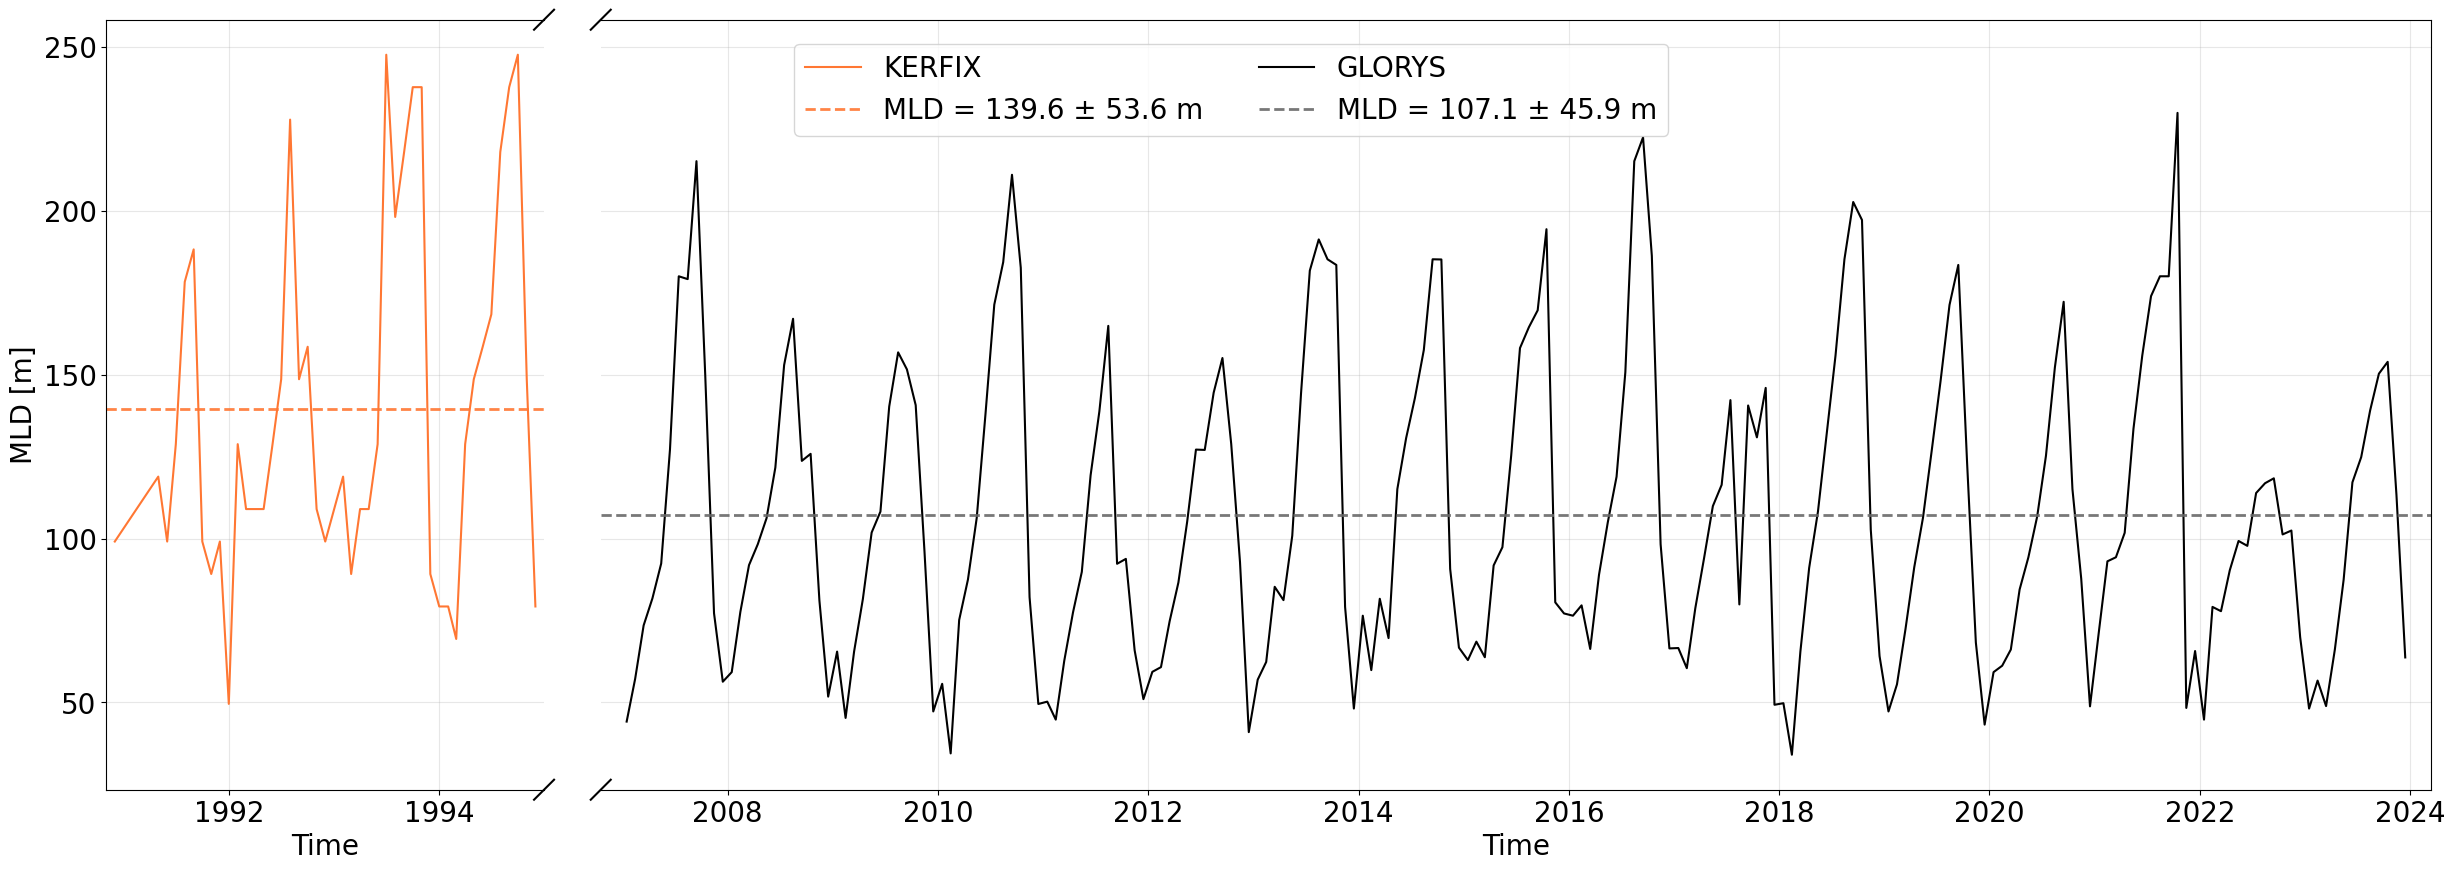

In [ ]:
ker = ds_ker["mld"].dropna(dim="TIME")
glo = ds_G["mld"].dropna(dim="time")

ker_xlim = (
    ker["TIME"].min().values - np.timedelta64(30, "D"),
    ker["TIME"].max().values + np.timedelta64(30, "D")
)
glo_xlim = (
    glo["time"].min().values - np.timedelta64(90, "D"),
    glo["time"].max().values + np.timedelta64(90, "D")
)

ker_span = (ker_xlim[1] - ker_xlim[0]) / np.timedelta64(1, "D")
glo_span = (glo_xlim[1] - glo_xlim[0]) / np.timedelta64(1, "D")

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(30, 10),
    gridspec_kw={"width_ratios": [ker_span, glo_span], "wspace": 0.05}
)

ax1.plot(ker["TIME"].values, ker.values, color="#FF7733", lw=1.5, ms=4, label="KERFIX")
ax2.plot(glo["time"].values, glo.values, color="black", lw=1.5, label="GLORYS")

ax1.set_xlim(*ker_xlim)
ax2.set_xlim(*glo_xlim)

import matplotlib.dates as mdates
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(labelleft=False, left=False)

d = 0.015
kwargs = dict(color="k", clip_on=False)
fig.canvas.draw()

pix = 10
dx1, dy1 = pix / ax1.bbox.width, pix / ax1.bbox.height
dx2, dy2 = pix / ax2.bbox.width, pix / ax2.bbox.height

ax1.plot((1 - dx1, 1 + dx1), (-dy1, +dy1), transform=ax1.transAxes, **kwargs)
ax1.plot((1 - dx1, 1 + dx1), (1 - dy1, 1 + dy1), transform=ax1.transAxes, **kwargs)
ax2.plot((-dx2, +dx2), (-dy2, +dy2), transform=ax2.transAxes, **kwargs)
ax2.plot((-dx2, +dx2), (1 - dy2, 1 + dy2), transform=ax2.transAxes, **kwargs)
ker_mean, ker_std = float(ker.mean().values), float(ker.std().values)
glo_mean, glo_std = float(glo.mean().values), float(glo.std().values)

ax1.axhline(ker_mean, color="#FF7733", ls="--", lw=2, alpha=0.9, label=f"MLD = {ker_mean:.1f} ± {ker_std:.1f} m")
ax2.axhline(glo_mean, color="dimgray", ls="--", lw=2, alpha=0.9, label=f"MLD = {glo_mean:.1f} ± {glo_std:.1f} m")

# ax1.text(
#     0.02, 0.98,
#     f"n={ker.size}\nmean={ker_mean:.1f} m\nstd={ker_std:.1f} m\nmin={ker_min:.1f} m\nmax={ker_max:.1f} m",
#     transform=ax1.transAxes, va="top", ha="left",
#     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
# )

# ax2.text(
#     0.02, 0.98,
#     f"n={glo.size}\nmean={glo_mean:.1f} m\nstd={glo_std:.1f} m\nmin={glo_min:.1f} m\nmax={glo_max:.1f} m",
#     transform=ax2.transAxes, va="top", ha="left",
#     bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
# )
ax1.set_ylabel("MLD [m]")
ax1.set_xlabel("Time")
ax2.set_xlabel("Time")
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.87))
plt.show()

fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_10_KERFIX_GLORYS_timeseries.png", dpi=300, bbox_inches="tight")